# Milestone Project 1: Food Vision Big

## Check GPU

Google colab offeres free GPUs, however not all of them are compatible with mixed precision training.

Google Colab offeres:
* K80 (not compatible)
* P100 (not compatible)
* Tesla T4 (compatible)

In [2]:
!nvidia-smi -L

GPU 0: NVIDIA GeForce GTX 1650 (UUID: GPU-f4cb0471-3cf4-3a88-76cc-3783fc94a541)


## Get helper function

In past modules, we've created a bunch of helper functions to do small tasks required for our notesbooks.
Rather than rewrite all of these, we can import a script and load them in from there.

In [3]:
# Import series of helper functions for the notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

## Use TensorFlow datasets to download data

In [4]:
# Get TensorFlow Datasets
import tensorflow_datasets as tfds

C:\Users\Priyesh\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# list all available datasets
datasets_list = tfds.list_builders() # Get all available datasets in TFDS
print("food101" in datasets_list)

True


In [6]:
# Load in the data (takes 5-6 minutes in Google colab)
(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train", "validation"],
                                             shuffle_files=True,
                                             as_supervised=True, # data gets returned in tuple format (data, label)
                                             with_info=True)

## Exploring the Food101 data from TensorFlow datasets

In [7]:
# Features of Food1-1 from TFDS
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [8]:
# Get the class names
class_names = ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [9]:
# Take one sample of the train data
train_one_sample = train_data.take(2) # Sample are in format (image_tensor, label)

In [10]:
# what does one sample of our training data look like?
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [11]:
# Output info about our training sample
for image, label in train_one_sample:
    print(f"""
          Image shape: {image.shape}
          Image datatype: {image.dtype}
          Target classfrom Food101 (tensor form): {label}
          Class name (str form): {class_names[label.numpy()]}
          """)


          Image shape: (489, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 90
          Class name (str form): spaghetti_bolognese
          

          Image shape: (512, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 93
          Class name (str form): steak
          


In [12]:
# What does our image tensor from TFDS's Food101 look like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[113,  50,  41],
        [111,  48,  39],
        [109,  46,  37],
        ...,
        [243, 226, 219],
        [242, 223, 217],
        [241, 222, 216]],

       [[117,  54,  45],
        [114,  51,  42],
        [111,  48,  39],
        ...,
        [230, 210, 201],
        [226, 203, 197],
        [221, 198, 190]],

       [[118,  58,  50],
        [116,  56,  48],
        [113,  53,  45],
        ...,
        [179, 149, 138],
        [169, 136, 127],
        [159, 127, 116]],

       ...,

       [[232, 241, 248],
        [232, 241, 248],
        [232, 241, 248],
        ...,
        [194, 183, 179],
        [194, 183, 179],
        [194, 183, 179]],

       [[231, 240, 247],
        [231, 240, 247],
        [232, 241, 248],
        ...,
        [194, 183, 179],
        [194, 183, 179],
        [194, 183, 179]],

       [[231, 240, 247],
        [231, 240, 247],
        [231, 240, 247],
        ...,
        [194, 183, 17

In [13]:
# min and max values of in our image tensor
import tensorflow as tf
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Plot an image from TensorFlow datasets

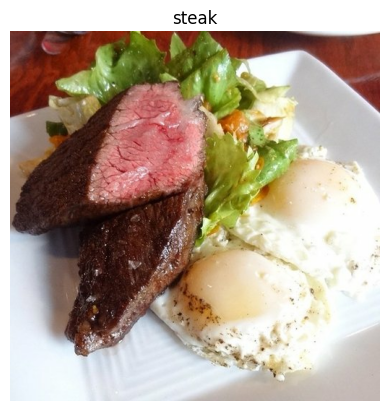

In [14]:
# Plot an image tensor
import matplotlib.pyplot as plt 
plt.imshow(image)
plt.title(class_names[label.numpy()]) # Add title to image to verify the label is associated with the right image 
plt.axis(False);

## Create preprocessing functions for our data

Neural networks perform best when data is in a certain way (e. g. batched, normalized, etc)

However, not all data (including data from TensorFlow datasets) comes like this.

So in order to get it ready for a neural network, you'll often have to write preprocessing functions and map it to your data.

What we know about our data:
* In `uint8` datatype
* Comprised of all different size tensors (different size images)
* Not scaled (the pixel values are between 0 & 255)

What we know models like:
* Data in `float32` dtype (or for mixed precision `float16` and `float32`)
* For batches, TensorFlow likes all of the tensors within a batch to be of the same size.
* Scaled (values between 0 & 1) also called normalized tensors generally perform better

With these points in mind, we've got a few things we can tackle with a preprocessing function.

Since we're going to be using an EfficientNetBX pretrained model from tf.keras.applicationss we don't need to rescale our data (these architecture have rescaling built-in).

This means our functions needs to :
1. Reshape our images to all the same size.
2. Convert the dtype of our image tensors from unit8 to float32

In [15]:
# Make a function for preprocessing images
def preprocess_img(image, label, img_shape=224):
    """
    Converts image datatype from 'unit8' -> 'float32' and reshapes image to [img_shape, colour_channells]
    """
    image = tf.image.resize(image, [img_shape, img_shape])
    return tf.cast(image, tf.float32), label

In [17]:
# Preprocess a single sample image and check the outputs
preprocessed_img = preprocess_img(image, label)[0]
print(f"Image before preprocessing:\n {image[:2]}..., \n Shape: {image.shape}, \nDatatype: {image.dtype} \n")
print(f"Image after preprocessing:\n{preprocessed_img[:2]}..., \nShape:{preprocessed_img.shape}, \nDatatype: {preprocessed_img.dtype}")

Image before preprocessing:
 [[[113  50  41]
  [111  48  39]
  [109  46  37]
  ...
  [243 226 219]
  [242 223 217]
  [241 222 216]]

 [[117  54  45]
  [114  51  42]
  [111  48  39]
  ...
  [230 210 201]
  [226 203 197]
  [221 198 190]]]..., 
 Shape: (512, 512, 3), 
Datatype: <dtype: 'uint8'> 

Image after preprocessing:
[[[113.87245   50.87245   41.87245 ]
  [109.091835  46.091835  37.091835]
  [112.06633   49.06633   40.06633 ]
  ...
  [243.97449  228.12238  224.41829 ]
  [238.95403  219.69382  213.59685 ]
  [230.43864  208.86722  202.40799 ]]

 [[117.31122   57.908165  49.908165]
  [112.93368   52.933674  44.933674]
  [108.37245   48.37245   40.37245 ]
  ...
  [155.57123  118.78546  107.759964]
  [141.12746  102.70395   88.056   ]
  [121.188446  79.85681   66.16293 ]]]..., 
Shape:(224, 224, 3), 
Datatype: <dtype: 'float32'>
